# Import config file which stores all hyperparameter values

In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadbeh_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 100
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

In [5]:
train_folder

['jaadbeh_with_c_g/train/']

# Load training data 

In [6]:
import os

In [7]:
import numpy as np


In [8]:
root = 'preprocessed_data/'+train_folder[0]
x_t_train, y_t_train = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')


In [9]:
print(x_t_train.shape, y_t_train.shape)

(24499, 16, 5) (24499, 1)


In [10]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

In [11]:
alpha = count_imbalance(y_t_train)

Negative class is minority class
Imbalance ratio: 0.58:0.42
Number of sample deficit: 3979


# Prepare a training function

In [12]:
import os
import torch 
import numpy as np
import utils.data_loader as Dataset
from torch.utils.data import DataLoader
import models.onedcnn_model_16frames as Onedcnn
from sklearn.model_selection import StratifiedKFold

# Random 5-fold straitified split Train set to Train/Val (80:20) 
* NOTE 1: Such validation set is not the same as PSI official validation set, it is simply a proportion of PSI train set. We use it to validate model and save a trained weight when its f1 reaches the highest score in the training history.
* NOTE 2:  Applying 5-fold straitified will produce 5 possible (non-overlapping) splits of Train/Val, therefore, we will get 5 trained models in the end.  

Fold 1:
Dataloader seed: 2726
[INFO]: Epoch 2 of 200
Training loss: 0.433, training acc: 50.000
Validation loss: 0.420, validation acc: 54.000
--------------------------------------------------

Best validation acc: 54.0

Saving best model for epoch: 2


Best validation f1: 0.38

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200
Training loss: 0.415, training acc: 56.000
Validation loss: 0.404, validation acc: 58.000
--------------------------------------------------

Best validation acc: 57.99999999999999

Saving best model for epoch: 3


Best validation f1: 0.48

Saving best model for epoch: 3

[INFO]: Epoch 4 of 200
Training loss: 0.398, training acc: 59.000
Validation loss: 0.381, validation acc: 59.000
--------------------------------------------------

Best validation acc: 59.0

Saving best model for epoch: 4


Best validation f1: 0.51

Saving best model for epoch: 4

[INFO]: Epoch 5 of 200
Training loss: 0.381, training acc: 61.000
Validation loss: 0.368, validation acc: 60

/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.435, training acc: 50.000
Validation loss: 0.424, validation acc: 50.000
--------------------------------------------------

Best validation acc: 50.0

Saving best model for epoch: 2


Best validation f1: 0.29

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200
Training loss: 0.420, training acc: 54.000
Validation loss: 0.410, validation acc: 56.000
--------------------------------------------------

Best validation acc: 56.00000000000001

Saving best model for epoch: 3


Best validation f1: 0.42

Saving best model for epoch: 3

[INFO]: Epoch 4 of 200
Training loss: 0.405, training acc: 58.000
Validation loss: 0.391, validation acc: 58.000
--------------------------------------------------

Best validation acc: 57.99999999999999

Saving best model for epoch: 4


Best validation f1: 0.48

Saving best model for epoch: 4

[INFO]: Epoch 5 of 200
Training loss: 0.391, training acc: 59.000
Validation loss: 0.379, validation acc: 59.000
-----------------------------------

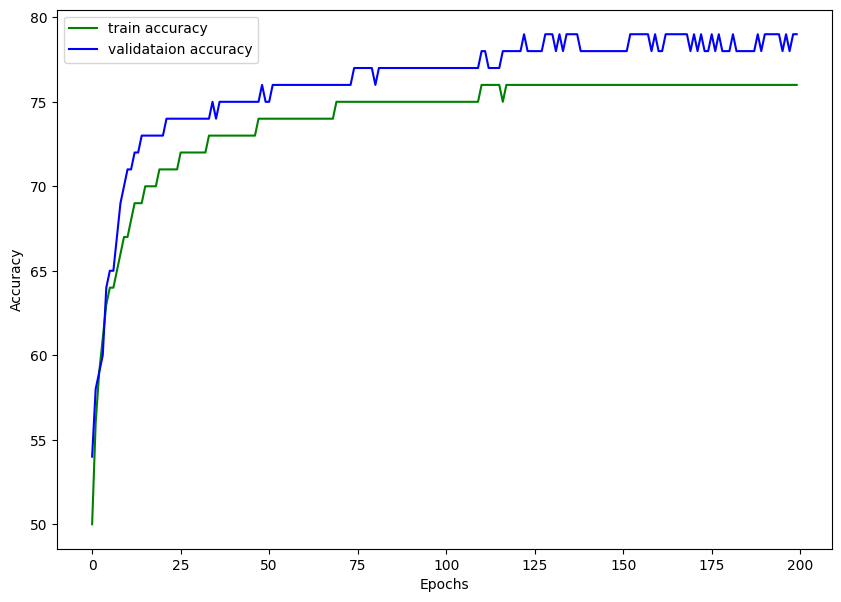

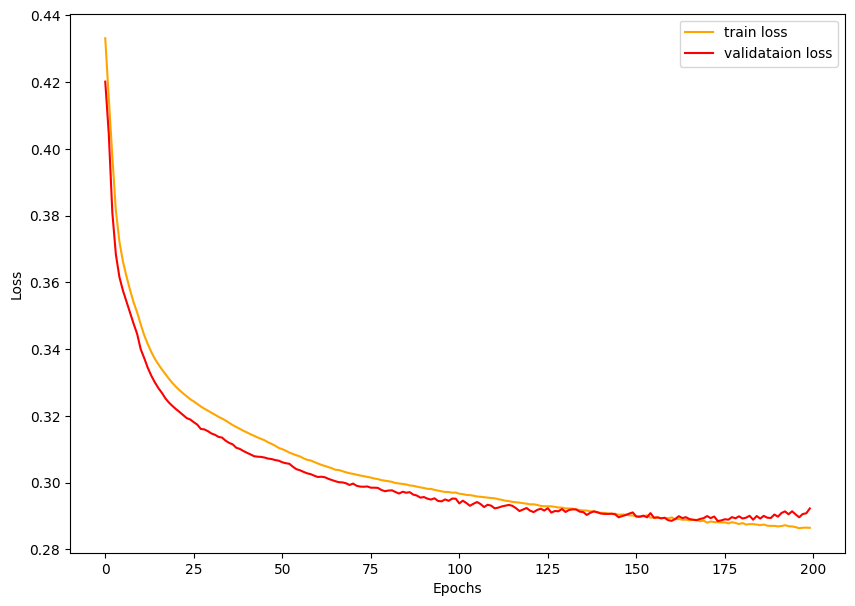

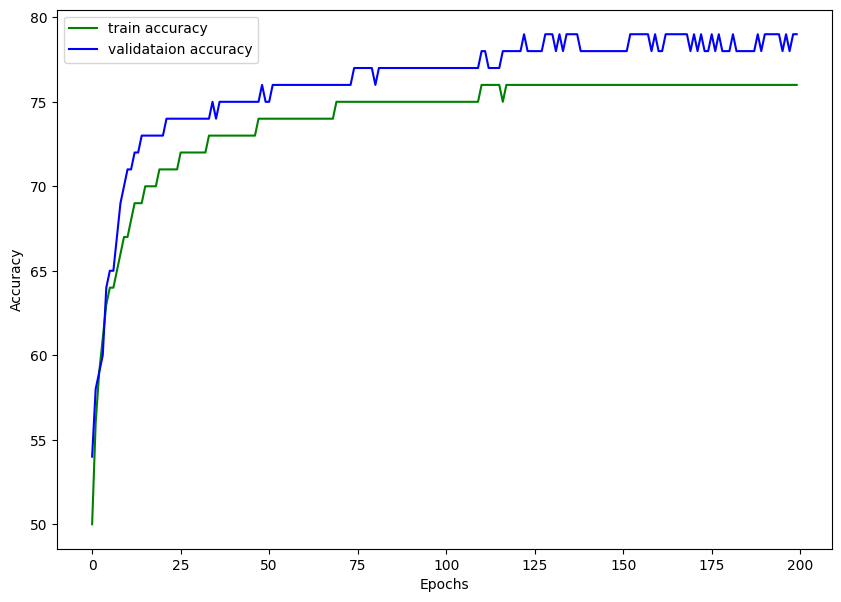

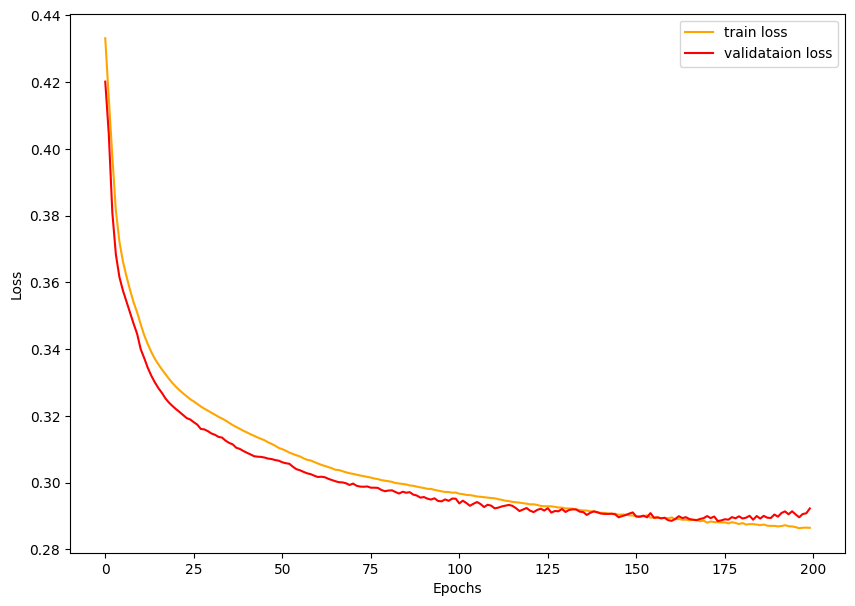

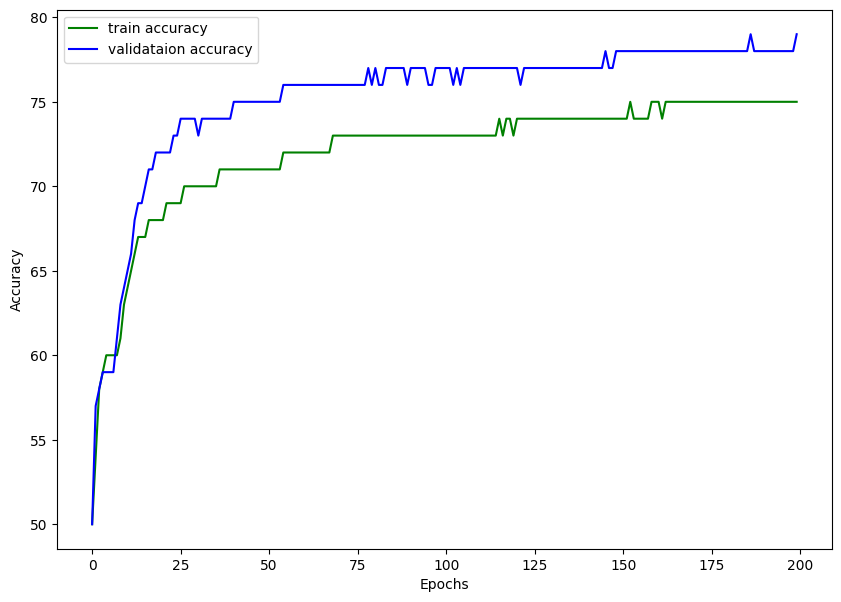

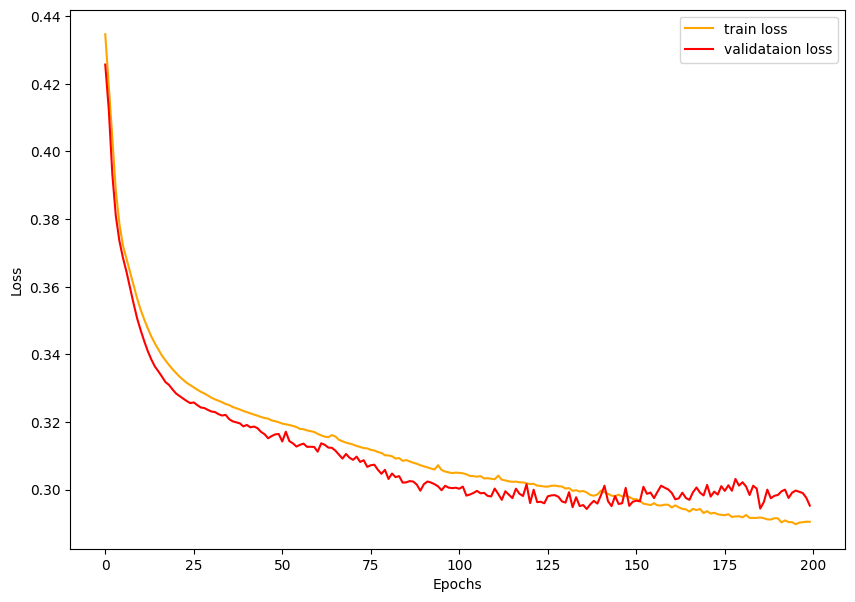

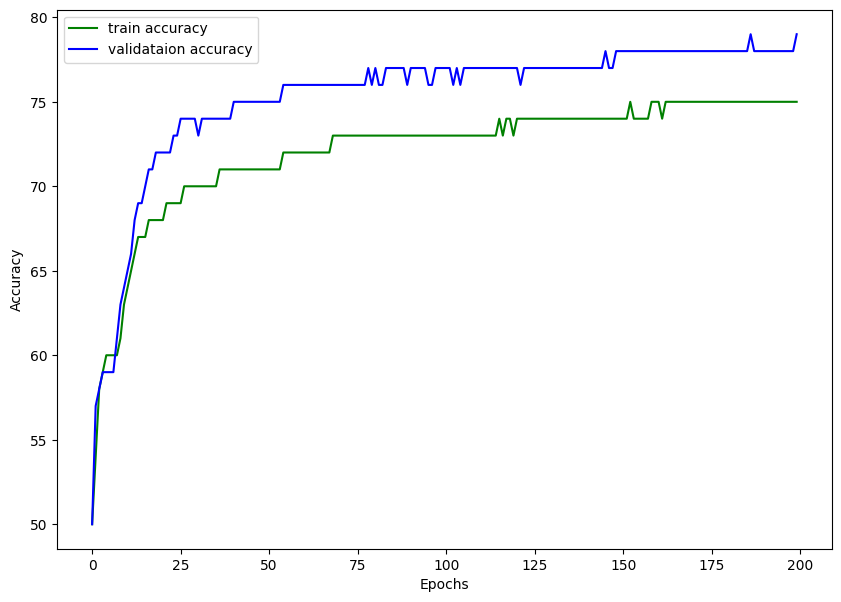

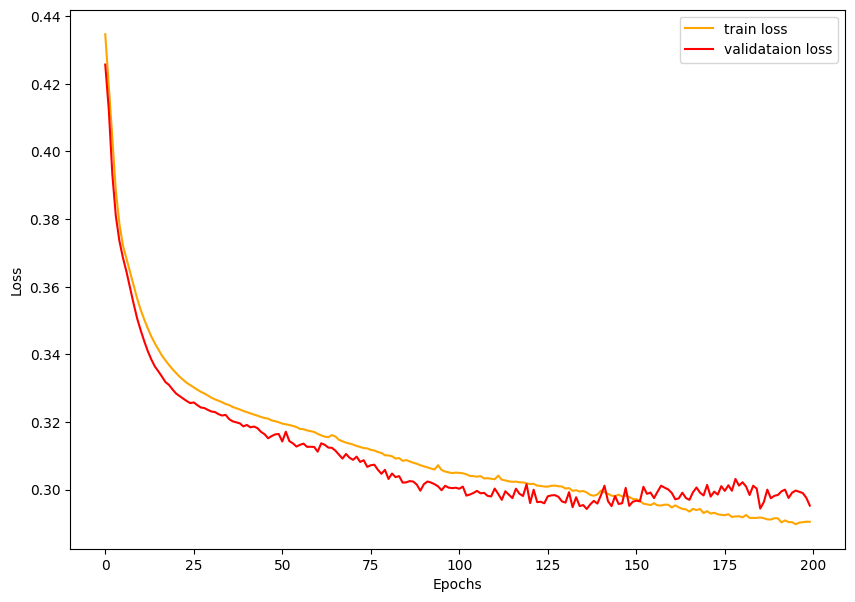

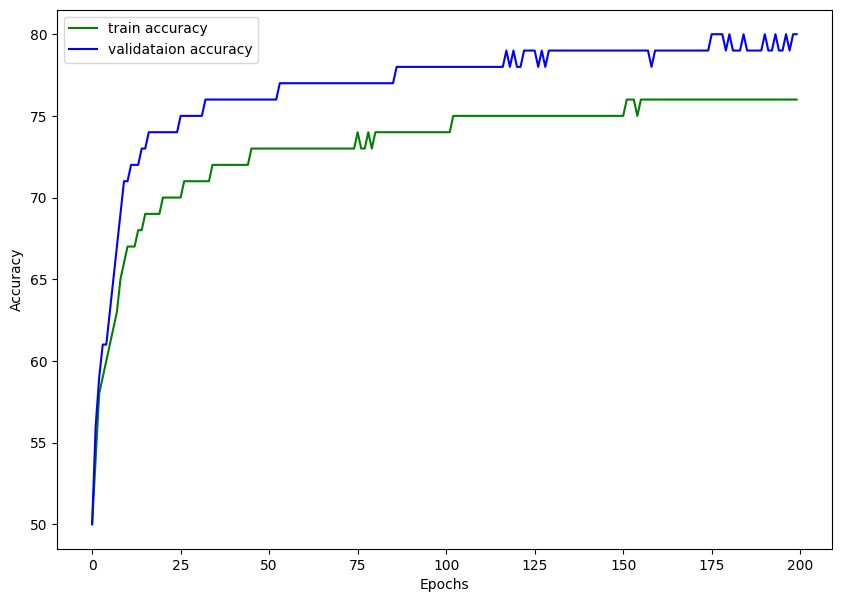

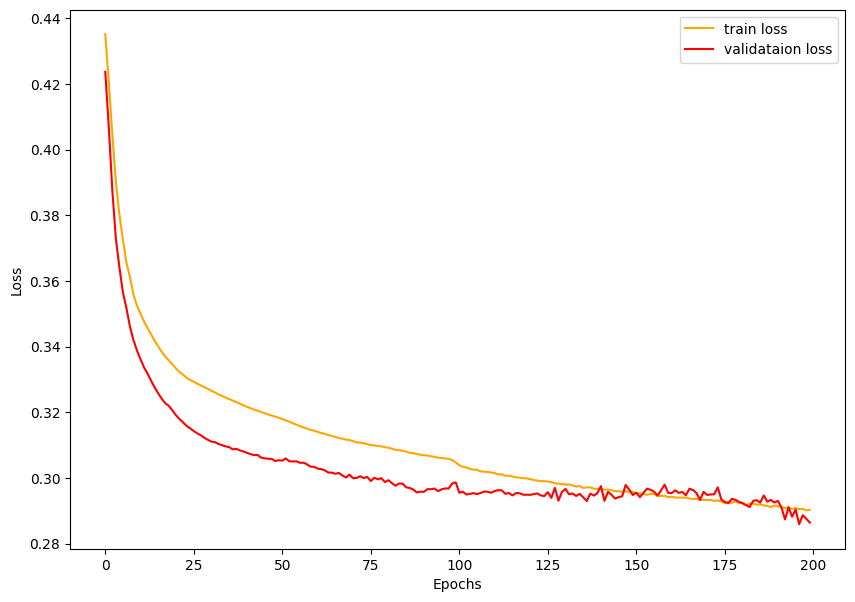

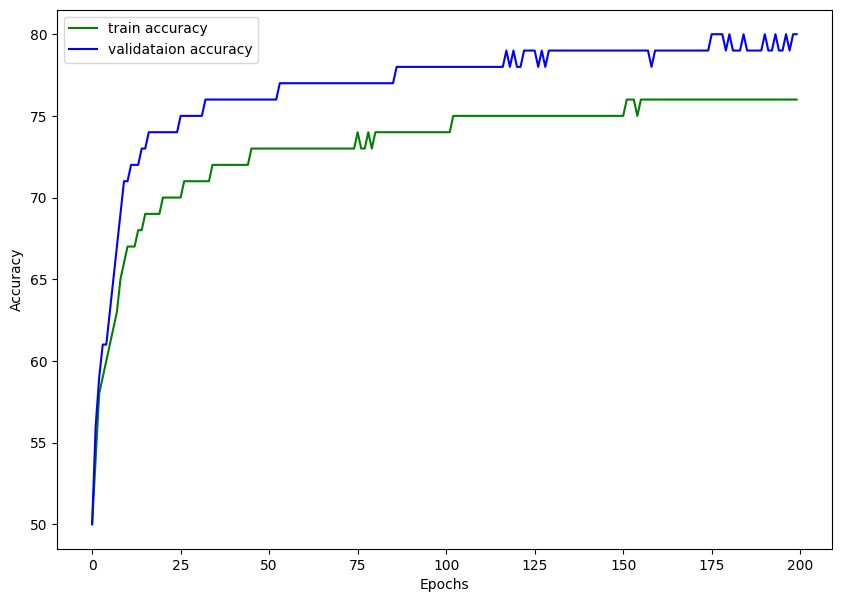

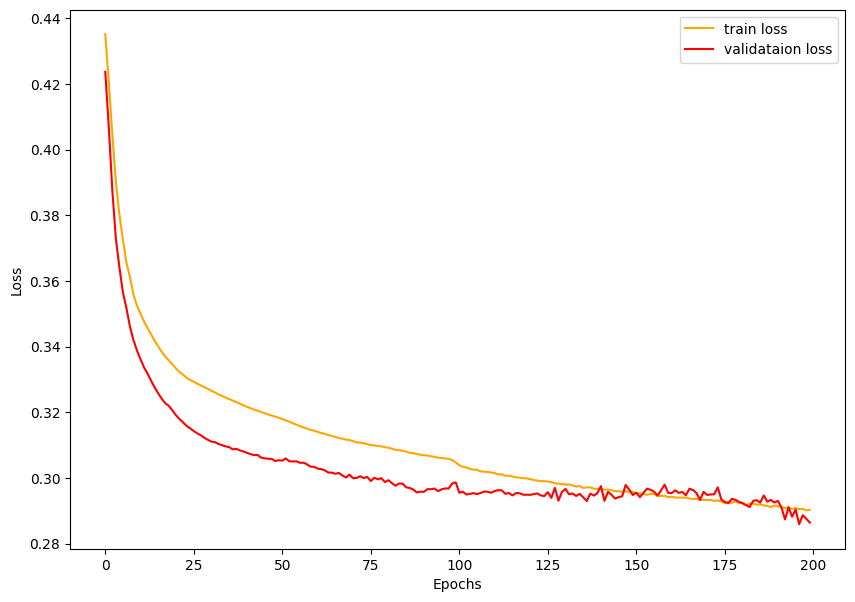

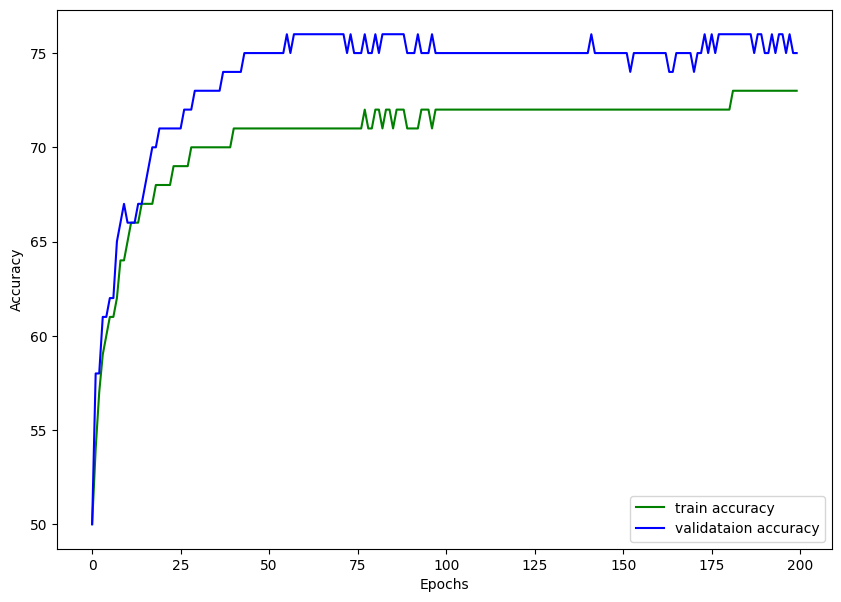

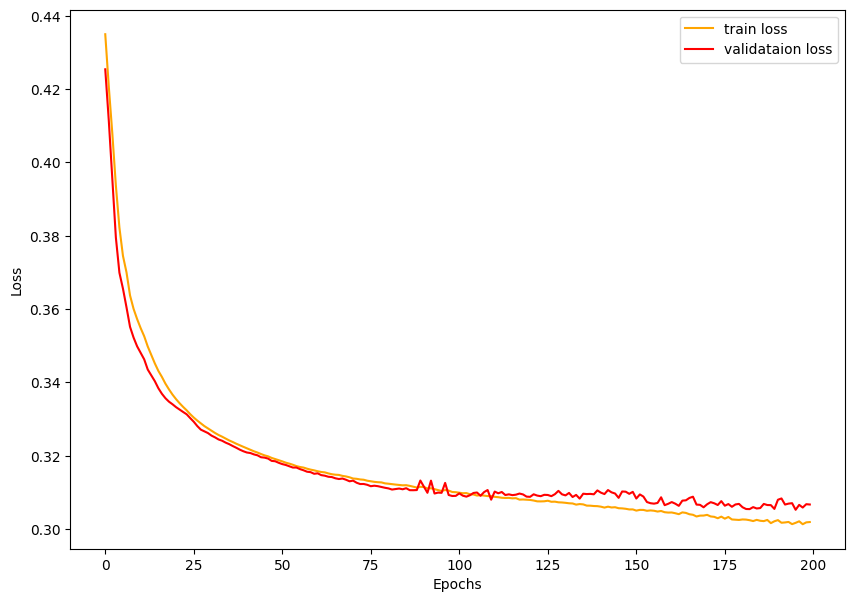

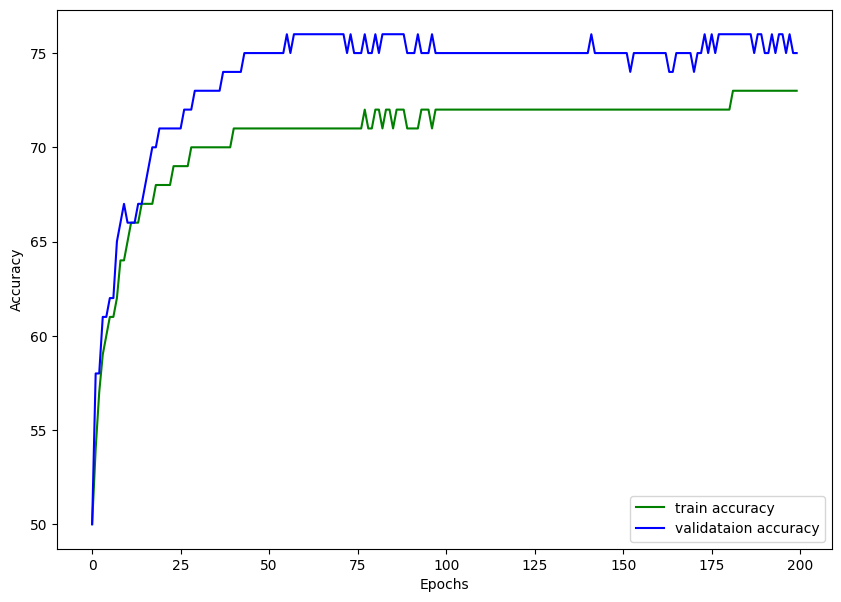

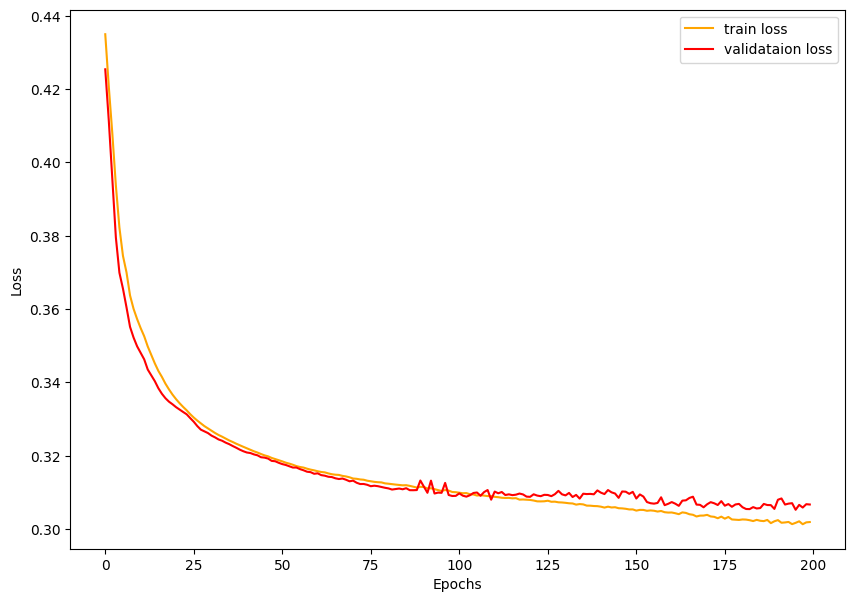

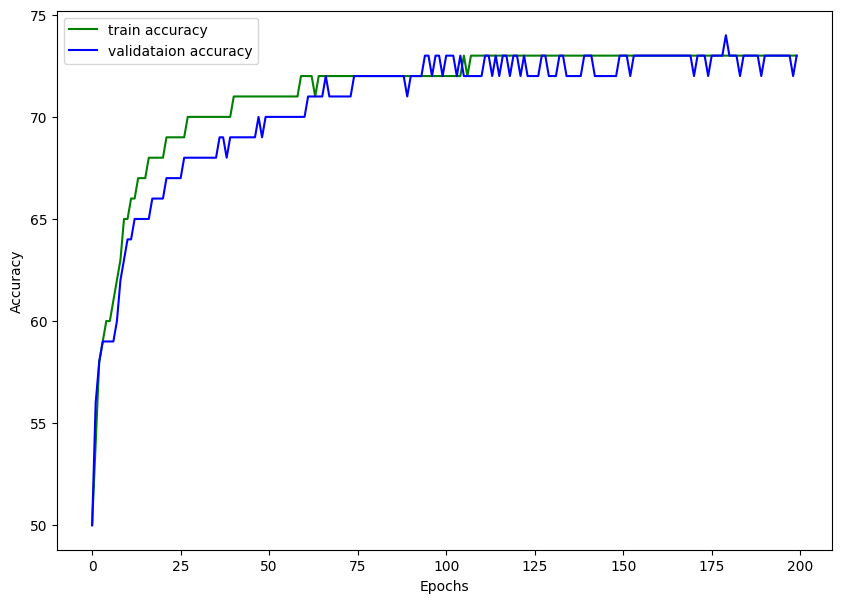

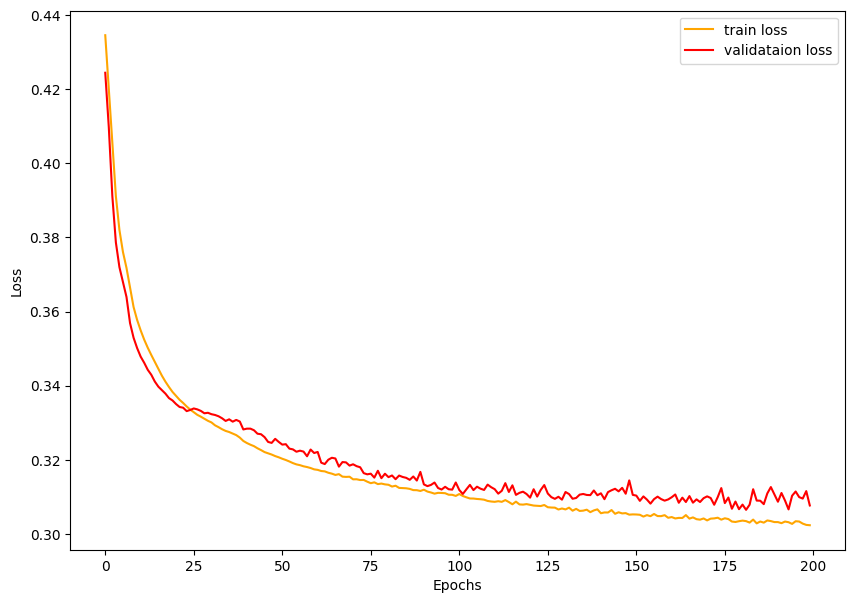

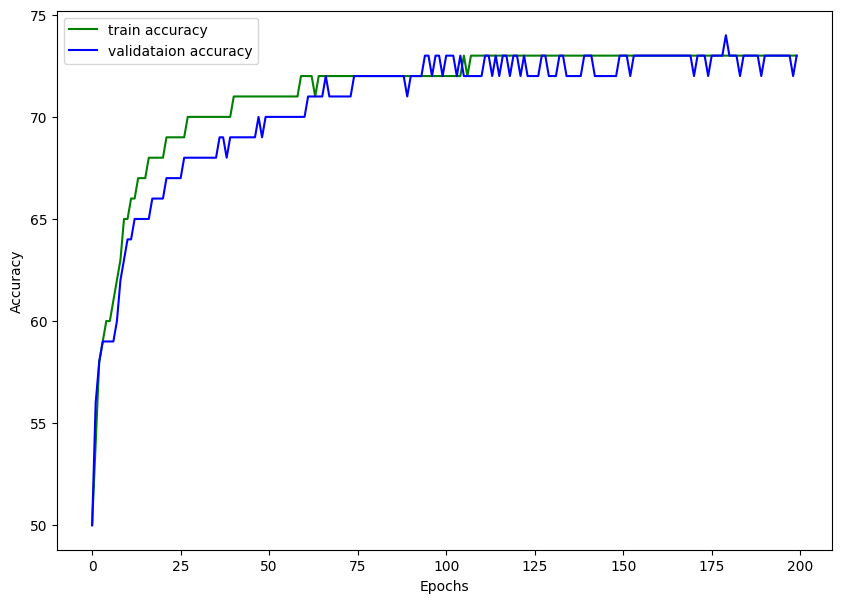

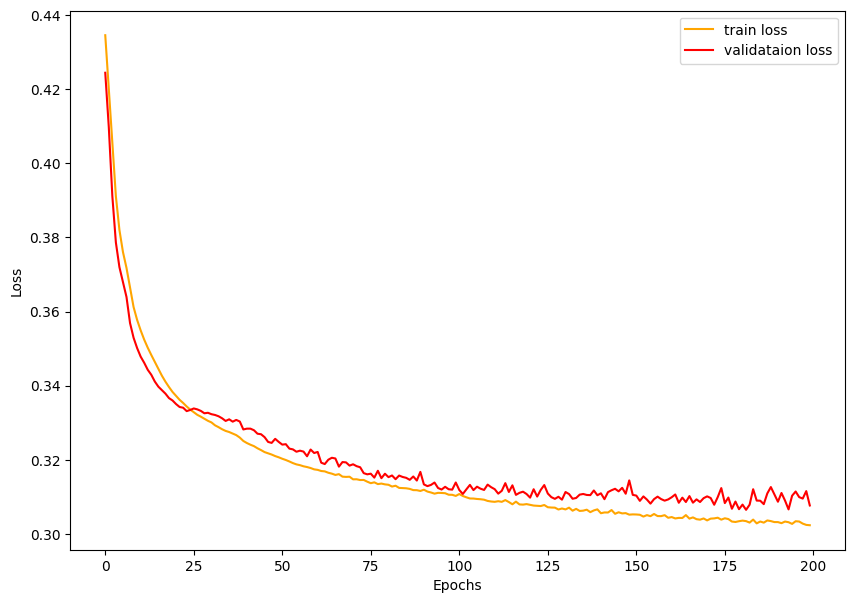

In [13]:
import shutil
from sklearn.model_selection import StratifiedKFold
import numpy as np

result_path = "training_results/"
if not os.path.isdir(result_path):
    os.mkdir(result_path)


if not os.path.isdir(save_model_folder_acc):
    os.mkdir(save_model_folder_acc)

if not os.path.isdir(save_model_folder_f1):
    os.mkdir(save_model_folder_f1)


def make_fold_folders(save_model_folder):
    for i in range(1, 6):
        save_pth = save_model_folder+f"fold_{i}"
        os.makedirs(save_pth, exist_ok=False)

make_fold_folders(save_model_folder_acc)
make_fold_folders(save_model_folder_f1)

#start from here to save config to the folder of trained models 
config_1 = save_model_folder_acc+config_path.split('/')[-1]
config_2 = save_model_folder_f1+config_path.split('/')[-1]
config_list = [config_1, config_2]


for config_name in config_list:
    shutil.copy(config_path, config_name)

Stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=ran_2)

for i, (train_index, val_index) in enumerate(Stratified_kfold.split(x_t_train, y_t_train)):
    print(f"Fold {i+1}:")
    save_fold_folder_acc = save_model_folder_acc+'fold_{0}/'.format(str(i+1))
    save_fold_folder_f1 = save_model_folder_f1+'fold_{0}/'.format(str(i+1))
    
    x_train = torch.FloatTensor(x_t_train)[train_index]
    y_train = torch.FloatTensor(y_t_train)[train_index]
    x_val = torch.FloatTensor(x_t_train)[val_index]
    y_val = torch.FloatTensor(y_t_train)[val_index]
    
    train_data = Dataset.TrajectoryData(x_train, y_train)
    val_data = Dataset.TrajectoryData(x_val, y_val)
    
    train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
    val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)
    Onedcnn.train_1dcnn_addfeature(train_loader, val_loader, save_fold_folder_acc, save_fold_folder_f1, loss_name, alpha)





